# Analyzing Gender Representation in the 2008 Summer Olympics

Almost 1900 medals were awarded in the 2008 Summer Olympics, across both male and female categories in many sports. Although there were so many medals awarded, there may not be an even distribution between male and female athletes. With that in mind, this analysis seeks to answer questions of gender equality or inequality in the 2008 Summer Olympic games.


First, load all necessary libraries for this project:
- Pandas
- Seaborn
- Matplotlib.pyplot

In [85]:
#Import necessary libraries

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Import data from the 'olympics_08_medalists.csv' dataset, which contains all of the information we need for this project.

In [86]:
#Read in data

data = pd.read_csv('data/olympics_08_medalists.csv')

data

,medalist_name,male_archery,female_archery,male_athletics,female_athletics,male_badminton,female_badminton,male_baseball,male_basketball,female_basketball,...,female_beach volleyball,male_volleyball,female_volleyball,male_water polo,female_water polo,male_weightlifting,female_weightlifting,male_freestyle wrestling,female_freestyle wrestling,male_greco-roman wrestling
0,Aaron Armstrong,NaN,NaN,gold,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron Peirsol,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Abdullo Tangriev,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abeer Abdelrahman,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,bronze,NaN,NaN,NaN
4,Abhinav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1870,Éver Banega,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1871,Ólafur Stefánsson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1872,Óscar Brayson,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1873,Łukasz Pawłowski,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This data has a column for every sport, both male and female, even though the vast majority of cells are empty! To tidy this up, we can melt this into three columns:

- 'medalist_name'
- 'Sport'
- 'Medal'

In [90]:
#Melt data to get create columns for name, sport, and medal and remove any null values

col_names = list(data.columns)
col_names.pop(0)

df_melted = pd.melt(data,
                    id_vars = ['medalist_name'],
                    value_vars = col_names,
                    var_name = 'Sport',
                    value_name = 'Medal')

df_clean = df_melted.dropna()

df_clean

,medalist_name,Sport,Medal
177,Bair Badënov,male_archery,bronze
676,Ilario Di Buò,male_archery,silver
682,Im Dong-hyun,male_archery,gold
760,Jiang Lin,male_archery,bronze
920,Lee Chang-hwan,male_archery,gold
...,...,...,...
130932,Steeve Guénot,male_greco-roman wrestling,gold
131159,Yannick Szczepaniak,male_greco-roman wrestling,bronze
131162,Yavor Yanakiev,male_greco-roman wrestling,bronze
131200,Yury Patrikeyev,male_greco-roman wrestling,bronze


This data still isn't tidy! Next, we can split the 'Sport' column into two new columns: 'Gender' and 'Event'.

We can then change the index to 'medalist_name', so that each row is named after an entry (athlete).

In [ ]:
##Complete tidy data form

#Split sport into gender and event columns
df_clean[['Gender', 'Event']] = df_clean['Sport'].str.split("_", expand = True)
df_clean = df_clean.drop('Sport', axis = 1)

#Sort data frame
df_clean.sort_values(by = ['Event', 'Gender', 'Medal'])

#Make medalist name the index, and remove the old index
olympics = df_clean.set_index('medalist_name')

#Preview data frame
olympics

/var/folders/4j/zprph1kj63v6396p77j3y9th0000gn/T/ipykernel_65498/2681779830.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[['Gender', 'Event']] = df_clean['Sport'].str.split("_", expand = True)
/var/folders/4j/zprph1kj63v6396p77j3y9th0000gn/T/ipykernel_65498/2681779830.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[['Gender', 'Event']] = df_clean['Sport'].str.split("_", expand = True)


,Medal,Gender,Event
medalist_name,,,
Bair Badënov,bronze,male,archery
Ilario Di Buò,silver,male,archery
Im Dong-hyun,gold,male,archery
Jiang Lin,bronze,male,archery
Lee Chang-hwan,gold,male,archery
...,...,...,...
Steeve Guénot,gold,male,greco-roman wrestling
Yannick Szczepaniak,bronze,male,greco-roman wrestling
Yavor Yanakiev,bronze,male,greco-roman wrestling


### Now we have **TIDY DATA**!!

Let's check our requirements:
1. Every row is an observation ✅:
    - Each row in this data frame is named after a medalist, whose information lies in that row 
2. Every column is a variable ✅:
    - 'Medal' measures the medal level of the athlete
    - 'Gender' measures whether an athlete is male or female
    - 'Event' names the event the athlete earned a medal in
3. Every cell is a corresponding piece of data ✅:
    - Each cell in the data frame contains data aligning with the column and row

## Now, we can visualize our data!

First, let's construct a pie chart to measure the overall share of total medals by gender.

<Axes: title={'center': 'Medal Count by Gender'}, ylabel='count'>

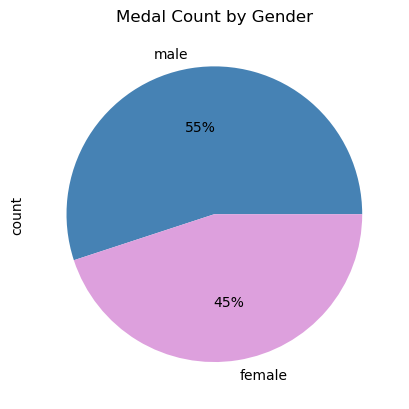

In [ ]:
#Pie chart of total medal count by gender

olympics['Gender'].value_counts().plot(kind = 'pie', title = 'Medal Count by Gender', autopct='%1.0f%%', colors = ['steelblue', 'plum'])

Next, let's create a pivot table that contains the medal counts by gender for each Olympic sport! This will allow us to further break down our gender analysis.

In [ ]:
#Construct pivot table for count of medals for each sport by gender

gender_data = olympics.pivot_table(index = 'Event',
                                   columns = 'Gender',
                                   values = 'Medal',
                                   aggfunc = 'count',
                                   fill_value = 0)

gender_data

Gender,female,male
Event,,
archery,9,11
artistic gymnastics,20,29
association football,54,55
athletics,81,85
badminton,10,12
baseball,0,72
basketball,36,35
beach volleyball,6,6
bmx,3,3


Using this data, we can construct a **heatmap**, which shows the gender distribution of medals by sport. A sport with gender equality will have very similar colors for male and female, whereas one with more inequality will have different colors for each gender.

Text(0.5, 1.0, 'Gender Distribution of Medals by Sport')

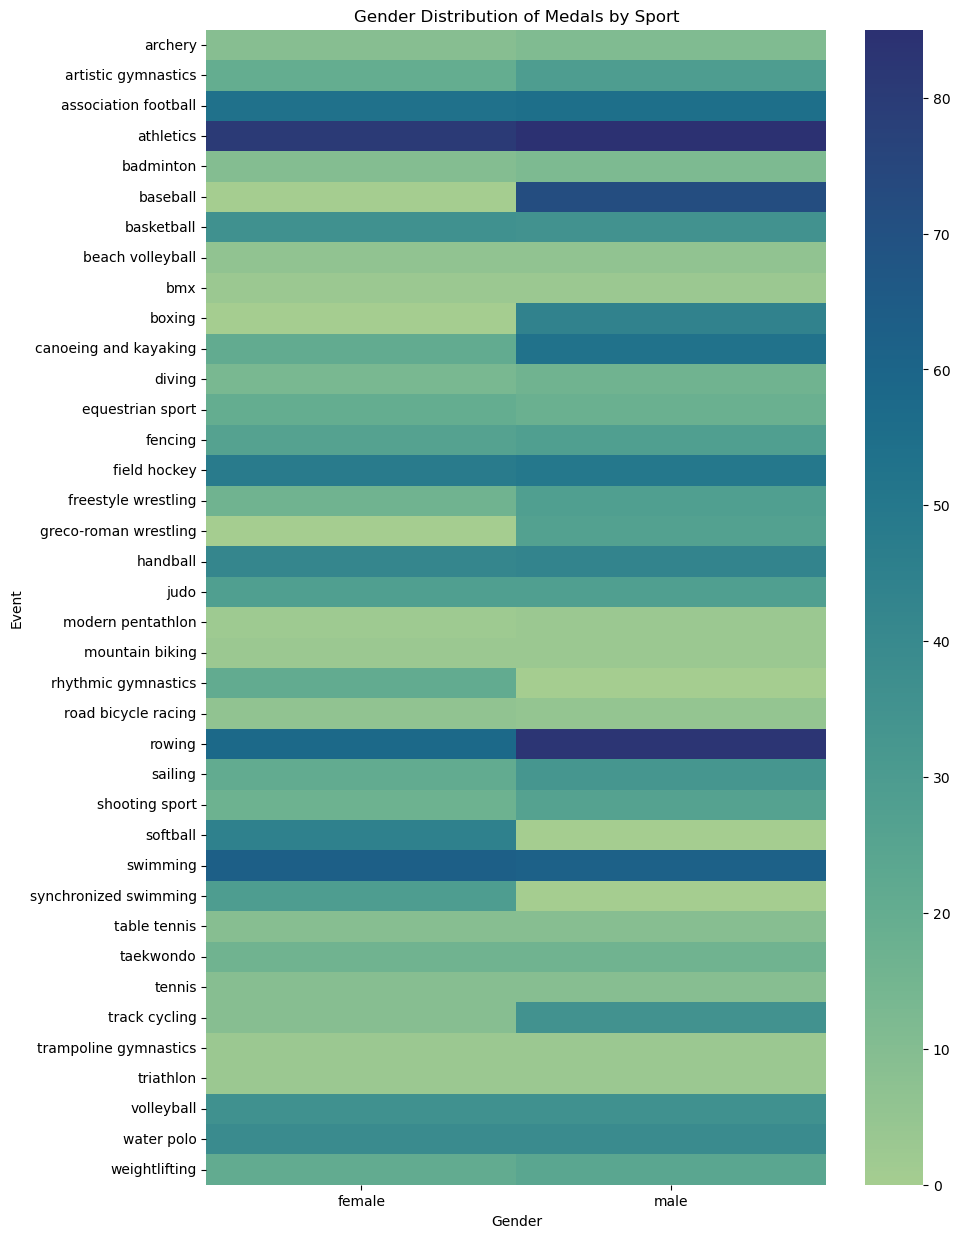

In [93]:
#Heatmap of gender distribution of medals by sport

plt.figure(figsize = (10,15))
sns.heatmap(gender_data, cmap = 'crest')
plt.title('Gender Distribution of Medals by Sport')

# Conclusions

Now that we have constructed and visualized our tidy data for the Olympics, we can draw some conclusions and answer some questions! 

1. Overall, is there a gender imbalance in medals awarded at the 2008 Olympics?
    - In the Olympics, 55% of medals were awarded to males, compared to 45% to females. There is a slight difference, but it is not extremely large.

2. What sports have the most gender equality/inequality?
    - Based on the pivot table and heatmap, sports that have very similar colors, such as basketball, judo, volleyball, and water polo award very similar, if not the same, number of medals to males and females. To determine the exact difference, the pivot table can be utilized.
    - Based on the pivot table and heatmap, sports that have very different colors, such as baseball, softball, boxing, synchronized swimming, and track cycling, award very different numbers of medals to male and female athletes. For sports such as baseball and softball, which are one-gender sports, this stark contract makes sense, but other sports may have some more nuance and inequality.

While there are some sports that have medals largely limited to either female or male athletes, in general, the 2008 Olympics seem to be relatively evenly distributed in medal awards by gender.